In [26]:
%pip install pandas numpy openpyxl matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Packages imported successfully.")

Packages imported successfully.


In [28]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name.lower() == "notebooks":
    BASE_DIR = NOTEBOOK_DIR.parent
else:
    BASE_DIR = Path(r"C:\GEO_Breast_Reliability")

DATA_DIR = BASE_DIR / "GSE81538"
PROCESSED_DIR = BASE_DIR / "processed"
RESULTS_DIR = BASE_DIR / "results"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Notebook directory:", NOTEBOOK_DIR)
print("Project directory:", BASE_DIR)
print("Data directory:", DATA_DIR)

Notebook directory: C:\GEO_Breast_Reliability\notebooks
Project directory: C:\GEO_Breast_Reliability
Data directory: C:\GEO_Breast_Reliability\GSE81538


In [29]:
expression_file = (
    DATA_DIR
    / "GSE81538_gene_expression_405_transformed.csv.gz"
)

pathology_file = (
    DATA_DIR
    / "GSE81538_pathology_consensus_key.xlsx"
)

mapping_file = (
    DATA_DIR
    / "GSE81538_map_transcriptID_geneSymbol.csv.gz"
)

files = {
    "Expression": expression_file,
    "Pathology": pathology_file,
    "Gene mapping": mapping_file,
}

for label, file_path in files.items():
    print(f"{label}:")
    print(f"  Path: {file_path}")
    print(f"  Exists: {file_path.exists()}")

Expression:
  Path: C:\GEO_Breast_Reliability\GSE81538\GSE81538_gene_expression_405_transformed.csv.gz
  Exists: True
Pathology:
  Path: C:\GEO_Breast_Reliability\GSE81538\GSE81538_pathology_consensus_key.xlsx
  Exists: True
Gene mapping:
  Path: C:\GEO_Breast_Reliability\GSE81538\GSE81538_map_transcriptID_geneSymbol.csv.gz
  Exists: True


In [30]:
expression = pd.read_csv(
    expression_file,
    compression="gzip",
    low_memory=False,
)

pathology = pd.read_excel(
    pathology_file,
    engine="openpyxl",
)

gene_mapping = pd.read_csv(
    mapping_file,
    compression="gzip",
    low_memory=False,
)

print("Expression shape:", expression.shape)
print("Pathology shape:", pathology.shape)
print("Gene mapping shape:", gene_mapping.shape)

Expression shape: (18802, 406)
Pathology shape: (47, 3)
Gene mapping shape: (80883, 1)


In [31]:
print("Expression columns:")
print(expression.columns.tolist()[:20])

print("\nPathology columns:")
print(pathology.columns.tolist())

print("\nGene-mapping columns:")
print(gene_mapping.columns.tolist())

Expression columns:
['Unnamed: 0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19']

Pathology columns:
['Key', 'Unnamed: 1', 'Unnamed: 2']

Gene-mapping columns:
['transcriptID\tgeneSymbol']


In [32]:
display(expression.head())
display(pathology.head())
display(gene_mapping.head())

,Unnamed: 0,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19,T20,T21,T22,T23,T24,T25,T26,T27,T28,T29,T30,T31,T32,T33,T34,T35,T36,T37,T38,T39,T40,T41,T42,T43,T44,T45,T46,T47,T48,T49,...,T356,T357,T358,T359,T360,T361,T362,T363,T364,T365,T366,T367,T368,T369,T370,T371,T372,T373,T374,T375,T376,T377,T378,T379,T380,T381,T382,T383,T384,T385,T386,T387,T388,T389,T390,T391,T392,T393,T394,T395,T396,T397,T398,T399,T400,T401,T402,T403,T404,T405
0,A1BG,1.590427,0.782005,5.124489,3.537580,3.874691,2.272538,3.550594,3.136737,3.161802,3.151932,3.497633,1.961995,3.631561,3.544290,2.386028,1.843249,3.244755,2.188470,2.402527,0.795770,3.046153,1.991473,3.864399,3.899909,3.082804,1.706630,2.732762,2.624347,3.977895,0.980528,3.943785,3.616986,1.180831,4.668346,1.812331,2.791270,2.153686,-0.100649,2.179515,2.349054,4.365390,3.157309,2.893070,2.783516,3.907058,2.965861,3.801611,2.441532,1.773729,...,3.538586,4.391217,2.771130,3.911523,3.463763,3.266277,2.868520,2.473857,3.912993,2.828041,3.935869,4.510176,4.586879,1.519618,3.961982,3.617913,3.591158,3.233997,2.016215,3.178646,2.346388,2.788661,3.688376,3.218707,4.132225,5.297038,3.457067,2.780748,3.297015,3.589374,3.898516,3.512073,2.832179,2.741478,2.566608,2.877995,3.461101,3.378428,3.198886,4.120862,4.098176,3.495086,3.561725,4.623393,4.188254,2.779785,3.069689,1.135712,3.708821,3.045782
1,A1CF,-3.321928,-3.321928,-3.321928,-2.962358,-3.247635,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.196173,-3.321928,-3.321928,-3.157947,-2.987143,-3.321928,-3.321928,-2.999210,-3.321928,-3.321928,-3.079481,-3.321928,-2.922254,-3.268117,-3.228218,-3.321928,-3.321928,-3.050679,-3.180020,-3.321928,-3.321928,-3.321928,-3.321928,-3.271774,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.181339,-3.235205,-3.186652,-3.206183,-3.276338,-3.321928,-3.321928,-3.202082,-3.321928,...,-3.321928,-3.321928,-3.321928,-3.046776,-3.265302,-3.268655,-3.321928,-3.321928,-3.321928,-3.213674,-3.321928,-3.321928,-3.205076,-3.101584,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.025040,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.266674,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928,-3.183435,-3.321928,-3.207230,-3.321928,-3.273963,-3.321928,-3.321928,-3.185844,-3.321928,-3.211343,-3.210499,-3.237576,-3.321928
2,A2LD1,1.484932,2.455667,1.707960,3.092352,2.755753,1.680052,2.708003,2.757847,1.372637,2.907377,1.610877,3.217761,1.597972,0.543120,1.583224,1.583045,2.766364,2.830138,3.056561,0.987064,2.432954,1.623032,2.890598,2.330526,3.386655,2.355278,2.405520,2.295722,2.431757,3.215258,4.087644,2.921802,2.208033,3.157157,3.088372,1.294471,2.730506,3.001961,0.640054,3.014846,2.188365,2.477252,2.713816,3.465105,1.940236,2.130217,2.761150,2.305201,1.853158,...,2.331627,2.463111,2.595263,2.024038,2.452407,1.830439,1.689191,1.498576,0.723199,3.199272,2.246286,3.385902,2.623776,3.083954,2.615226,2.150510,2.903736,1.494176,2.314816,2.276489,2.320858,3.081577,2.113725,1.763345,2.483315,1.467310,3.061397,2.615374,2.327495,1.310119,1.784152,1.646593,3.056123,2.005946,1.829687,2.231684,2.142627,1.919673,3.857979,2.441960,2.689509,1.886163,3.759563,2.857039,2.635550,2.202699,4.509565,2.616566,3.332391,2.114228
3,A2M,10.532488,4.758267,5.989012,7.436564,6.752650,6.035074,7.284499,5.581803,6.187325,7.423513,6.505761,7.254571,7.245814,7.215918,5.845969,5.679714,6.924969,7.065455,7.362096,6.913897,6.668096,6.830439,9.363927,5.340487,6.676673,7.034639,7.571163,7.927188,5.387430,6.814822,6.439756,7.189262,6.767210,6.204886,6.433237,6.973942,8.462191,6.931284,8.215213,5.329918,6.262659,6.474256,6.638012,5.237261,4.694713,6.675805,5.581680,6.835665,7.630627,...,7.073963,6.581579,8.113410,5.551198,7.499567,7.331103,7.391080,7.964124,6.334936,6.292682,6.768499,6.831067,6.232536,6.126733,6.911961,7.515414,6.839386,5.802571,6.201155,6.259618,7.056431,6.779820,7.520217,6.669916,6.285242,7.239861,8.193163,7.057198,7.911574,7.471170,6.158654,7.997474,

,Key,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,ER & PR,NaN,NaN
2,0,0,negative
3,1,1-10%,negative (Sweden) or positive (ASCO/CAP) depen...
4,2,11-50%,positive


,transcriptID\tgeneSymbol
0,uc001aaa.3\tDDX11L1
1,uc010nxr.1\tDDX11L1
2,uc010nxq.1\tDDX11L9
3,uc009vis.3\tWASH7P
4,uc009vjc.1\tWASH7P


In [33]:
# Rename the first column to gene_symbol
expression = expression.rename(
    columns={expression.columns[0]: "gene_symbol"}
)

# Set gene symbols as the row index
expression = expression.set_index("gene_symbol")

# Ensure all expression measurements are numeric
expression = expression.apply(
    pd.to_numeric,
    errors="coerce"
)

print("Expression matrix shape:", expression.shape)
print("Number of genes:", expression.shape[0])
print("Number of samples:", expression.shape[1])
print("Missing expression values:", expression.isna().sum().sum())

display(expression.iloc[:5, :10])

Expression matrix shape: (18802, 405)
Number of genes: 18802
Number of samples: 405
Missing expression values: 0


,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
gene_symbol,,,,,,,,,,
A1BG,1.590427,0.782005,5.124489,3.537580,3.874691,2.272538,3.550594,3.136737,3.161802,3.151932
A1CF,-3.321928,-3.321928,-3.321928,-2.962358,-3.247635,-3.321928,-3.321928,-3.321928,-3.321928,-3.321928
A2LD1,1.484932,2.455667,1.707960,3.092352,2.755753,1.680052,2.708003,2.757847,1.372637,2.907377
A2M,10.532488,4.758267,5.989012,7.436564,6.752650,6.035074,7.284499,5.581803,6.187325,7.423513
A2ML1,3.230358,3.831861,-3.081209,-2.008639,-2.755168,2.147659,-2.498165,-0.526405,-2.688875,-2.279001


In [34]:
%pip install GEOparse

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [35]:
import GEOparse

gse = GEOparse.get_GEO(
    geo="GSE81538",
    destdir=str(DATA_DIR),
    annotate_gpl=False,
    silent=False
)

print("Number of GEO samples:", len(gse.gsms))

23-Jul-2026 04:21:45 DEBUG utils - Directory C:\GEO_Breast_Reliability\GSE81538 already exists. Skipping.
23-Jul-2026 04:21:45 INFO GEOparse - File already exist: using local version.
23-Jul-2026 04:21:45 INFO GEOparse - Parsing C:\GEO_Breast_Reliability\GSE81538\GSE81538_family.soft.gz: 
23-Jul-2026 04:21:45 DEBUG GEOparse - DATABASE: GeoMiame
23-Jul-2026 04:21:45 DEBUG GEOparse - SERIES: GSE81538
23-Jul-2026 04:21:45 DEBUG GEOparse - PLATFORM: GPL11154
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155558
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155559
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155560
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155561
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155562
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155563
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155564
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155565
23-Jul-2026 04:21:45 DEBUG GEOparse - SAMPLE: GSM2155566
23-Jul-2026 04:21:45 DEBUG G

Number of GEO samples: 405


In [36]:
import re
import pandas as pd


def clean_name(text):
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return text.strip("_")


metadata_rows = []

for gsm_id, gsm in gse.gsms.items():
    row = {
        "gsm_id": gsm_id,
        "sample_id": gsm.metadata.get("title", [None])[0],
    }

    characteristics = gsm.metadata.get(
        "characteristics_ch1",
        []
    )

    for item in characteristics:
        if ":" not in item:
            continue

        key, value = item.split(":", 1)
        row[clean_name(key)] = value.strip()

    metadata_rows.append(row)

sample_metadata = pd.DataFrame(metadata_rows)

print("Metadata shape:", sample_metadata.shape)
display(sample_metadata.head())

Metadata shape: (405, 40)


,gsm_id,sample_id,tissue,er_ihc_routinestain_clinical_reading,er_ihc_routinestain_reading_2,er_ihc_routinestain_reading_3,er_ihc_restain_reading_1,er_ihc_restain_reading_2,er_ihc_restain_reading_3,er_consensus,pgr_ihc_routinestain_clinical_reading,pgr_routinestain_reading_2,pgr_routinestain_reading_3,pgr_restain_reading_1,pgr_restain_reading_2,pgr_restain_reading_3,pgr_consensus,her2_ihc_clinreading,her2_ihc_reading_2,her2_ihc_reading_3,her2_clinical_status,her2_sish_reading_1,her2_sish_reading_2,her2_sish_reading_3,her2_consensus,ki67_reading_1,ki67_reading_2,ki67_reading_3,ki67_consensus,nhg_reading_1_tubular,nhg_reading_1_pleomorph,nhg_reading_1_mitotic,nhg_reading_2_tubular,nhg_reading_2_pleomorph,nhg_reading_2_mitotic,nhg_reading_3_tubular,nhg_reading_3_pleomorph,nhg_reading_3_mitotic,nhg_consensus,pam50_subtype
0,GSM2155558,T1,breast tumor,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,80,70,85,80,3,3,3,3,3,3,3,3,3,3,Basal
1,GSM2155559,T2,breast tumor,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,40,25,25,25,3,3,3,3,3,2,3,3,3,3,Her2
2,GSM2155560,T3,breast tumor,3,3,3,3,3,3,3,1,0,1,0,0,1,1,2,2,2,1,2,1,1,1,30,30,40,30,3,3,2,3,3,3,3,3,1,3,LumB
3,GSM2155561,T4,breast tumor,3,3,3,3,3,3,3,3,2,2,2,1,1,2,3,3,3,1,1,1,1,1,20,10,22,20,3,3,2,3,2,1,3,3,1,2,Her2
4,GSM2155562,T5,breast tumor,3,3,3,3,3,3,3,1,1,0,1,1,1,1,2,1,1,1,4,4,4,0,30,15,20,20,3,3,3,3,3,1,3,3,1,2,LumB


In [37]:
[column for column in sample_metadata.columns
 if "er" in column.lower()]

['er_ihc_routinestain_clinical_reading',
 'er_ihc_routinestain_reading_2',
 'er_ihc_routinestain_reading_3',
 'er_ihc_restain_reading_1',
 'er_ihc_restain_reading_2',
 'er_ihc_restain_reading_3',
 'er_consensus',
 'her2_ihc_clinreading',
 'her2_ihc_reading_2',
 'her2_ihc_reading_3',
 'her2_clinical_status',
 'her2_sish_reading_1',
 'her2_sish_reading_2',
 'her2_sish_reading_3',
 'her2_consensus']

In [38]:
sample_metadata["er_consensus"].value_counts(
    dropna=False
).sort_index()

er_consensus
0     82
1      8
2     11
3    304
Name: count, dtype: int64

In [39]:
display(
    sample_metadata[
        ["gsm_id", "sample_id", "er_consensus"]
    ].head(10)
)

,gsm_id,sample_id,er_consensus
0,GSM2155558,T1,0
1,GSM2155559,T2,0
2,GSM2155560,T3,3
3,GSM2155561,T4,3
4,GSM2155562,T5,3
5,GSM2155563,T6,0
6,GSM2155564,T7,3
7,GSM2155565,T8,0
8,GSM2155566,T9,3
9,GSM2155567,T10,0


In [40]:
sample_metadata["er_consensus"] = pd.to_numeric(
    sample_metadata["er_consensus"],
    errors="coerce"
)

er_counts = (
    sample_metadata["er_consensus"]
    .value_counts(dropna=False)
    .sort_index()
)

print("ER consensus counts:")
display(er_counts)

ER consensus counts:


er_consensus
0     82
1      8
2     11
3    304
Name: count, dtype: int64

In [41]:
pathology_key = pd.read_excel(
    pathology_file,
    header=None,
    engine="openpyxl"
)

print(
    pathology_key.to_string(
        index=False,
        header=False
    )
)

                              Key                                                                                                                                                                NaN                                                          NaN
                              NaN                                                                                                                                                                NaN                                                          NaN
                          ER & PR                                                                                                                                                                NaN                                                          NaN
                                0                                                                                                                                                                  0                              

In [42]:
# Convert the expression matrix to:
# samples as rows and genes as columns
X = expression.T.copy()

metadata_indexed = (
    sample_metadata
    .drop_duplicates(subset="sample_id")
    .set_index("sample_id")
)

metadata_aligned = metadata_indexed.reindex(X.index)

print("Expression shape:", X.shape)
print("Metadata shape:", metadata_aligned.shape)

print(
    "Samples without matching metadata:",
    metadata_aligned["gsm_id"].isna().sum()
)

print(
    "Samples without ER consensus:",
    metadata_aligned["er_consensus"].isna().sum()
)

display(
    metadata_aligned[
        ["gsm_id", "er_consensus"]
    ].head(10)
)

Expression shape: (405, 18802)
Metadata shape: (405, 39)
Samples without matching metadata: 0
Samples without ER consensus: 0


,gsm_id,er_consensus
T1,GSM2155558,0
T2,GSM2155559,0
T3,GSM2155560,3
T4,GSM2155561,3
T5,GSM2155562,3
T6,GSM2155563,0
T7,GSM2155564,3
T8,GSM2155565,0
T9,GSM2155566,3
T10,GSM2155567,0


In [43]:
er_counts = (
    metadata_aligned["er_consensus"]
    .value_counts(dropna=False)
    .sort_index()
)

print("ER consensus category counts:")
print(er_counts)

ER consensus category counts:
er_consensus
0     82
1      8
2     11
3    304
Name: count, dtype: int64


In [44]:
X_sensitivity = X.copy()

y_sensitivity = (
    metadata_aligned["er_consensus"]
    .map({
        0: 0,
        1: 1,
        2: 1,
        3: 1
    })
    .astype(int)
)

print("Sensitivity-analysis shape:", X_sensitivity.shape)
print("\nSensitivity outcome counts:")
print(
    y_sensitivity.value_counts()
    .rename(index={0: "ER-negative", 1: "ER-positive"})
)

Sensitivity-analysis shape: (405, 18802)

Sensitivity outcome counts:
er_consensus
ER-positive    323
ER-negative     82
Name: count, dtype: int64


In [45]:
X_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_X_sensitivity_ER.pkl"
)

y_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_y_sensitivity_ER.pkl"
)

print("Sensitivity-analysis files saved.")

Sensitivity-analysis files saved.


In [46]:
# Recreate aligned expression and metadata
X = expression.T.copy()

metadata_indexed = (
    sample_metadata
    .drop_duplicates(subset="sample_id")
    .set_index("sample_id")
)

metadata_aligned = metadata_indexed.reindex(X.index)

metadata_aligned["er_consensus"] = pd.to_numeric(
    metadata_aligned["er_consensus"],
    errors="coerce"
)

# Primary analysis:
# 0 = ER-negative
# 2 and 3 = ER-positive
# 1 = borderline and excluded
primary_mask = metadata_aligned["er_consensus"].isin([0, 2, 3])

X_primary = X.loc[primary_mask].copy()

y_primary = (
    metadata_aligned.loc[primary_mask, "er_consensus"]
    .map({
        0: 0,
        2: 1,
        3: 1
    })
    .astype(int)
)

primary_metadata = metadata_aligned.loc[primary_mask].copy()
primary_metadata["er_binary"] = y_primary

# Sensitivity analysis:
# Treat code 1 as ER-positive
X_sensitivity = X.copy()

y_sensitivity = (
    metadata_aligned["er_consensus"]
    .map({
        0: 0,
        1: 1,
        2: 1,
        3: 1
    })
    .astype(int)
)

print("Primary dataset:", X_primary.shape)
print(y_primary.value_counts())

print("\nSensitivity dataset:", X_sensitivity.shape)
print(y_sensitivity.value_counts())

Primary dataset: (397, 18802)
er_consensus
1    315
0     82
Name: count, dtype: int64

Sensitivity dataset: (405, 18802)
er_consensus
1    323
0     82
Name: count, dtype: int64


In [47]:
cohort_summary = pd.DataFrame({
    "Analysis": [
        "Primary analysis",
        "Sensitivity analysis"
    ],
    "Total samples": [
        len(y_primary),
        len(y_sensitivity)
    ],
    "ER-negative": [
        int((y_primary == 0).sum()),
        int((y_sensitivity == 0).sum())
    ],
    "ER-positive": [
        int((y_primary == 1).sum()),
        int((y_sensitivity == 1).sum())
    ],
    "Genes": [
        X_primary.shape[1],
        X_sensitivity.shape[1]
    ]
})

display(cohort_summary)

,Analysis,Total samples,ER-negative,ER-positive,Genes
0,Primary analysis,397,82,315,18802
1,Sensitivity analysis,405,82,323,18802


In [48]:
cohort_summary = pd.DataFrame({
    "Analysis": [
        "Primary analysis",
        "Sensitivity analysis"
    ],
    "Total samples": [
        len(y_primary),
        len(y_sensitivity)
    ],
    "ER-negative": [
        int((y_primary == 0).sum()),
        int((y_sensitivity == 0).sum())
    ],
    "ER-positive": [
        int((y_primary == 1).sum()),
        int((y_sensitivity == 1).sum())
    ],
    "Genes": [
        X_primary.shape[1],
        X_sensitivity.shape[1]
    ]
})

display(cohort_summary)

,Analysis,Total samples,ER-negative,ER-positive,Genes
0,Primary analysis,397,82,315,18802
1,Sensitivity analysis,405,82,323,18802


In [49]:
# Save the primary-analysis data
X_primary.to_pickle(
    PROCESSED_DIR / "GSE81538_X_primary_ER.pkl"
)

y_primary.to_pickle(
    PROCESSED_DIR / "GSE81538_y_primary_ER.pkl"
)

primary_metadata.to_csv(
    PROCESSED_DIR / "GSE81538_primary_ER_metadata.csv"
)

# Save the sensitivity-analysis data
X_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_X_sensitivity_ER.pkl"
)

y_sensitivity.to_pickle(
    PROCESSED_DIR / "GSE81538_y_sensitivity_ER.pkl"
)

# Save the cohort summary
cohort_summary.to_csv(
    RESULTS_DIR / "GSE81538_cohort_summary.csv",
    index=False
)

print("All prepared datasets were saved successfully.")

All prepared datasets were saved successfully.


In [50]:
# Activate the 405-tumor sensitivity cohort for this copied notebook.
# The original 397-tumor notebook remains unchanged.

X_primary_397 = X_primary.copy()
y_primary_397 = y_primary.copy()

# Redirect the existing downstream analysis to the sensitivity cohort.
X_primary = X_sensitivity.copy()
y_primary = y_sensitivity.copy()

# Save all new sensitivity results in a separate folder.
RESULTS_DIR = BASE_DIR / "results" / "sensitivity_405"
FIGURES_DIR = BASE_DIR / "figures" / "sensitivity_405"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Active sensitivity-analysis dataset:", X_primary.shape)
print("ER-negative:", int((y_primary == 0).sum()))
print("ER-positive:", int((y_primary == 1).sum()))
print("Sensitivity results folder:", RESULTS_DIR)

# Safety checks
assert X_primary.shape == (405, 18802)
assert int((y_primary == 0).sum()) == 82
assert int((y_primary == 1).sum()) == 323

print("Sensitivity cohort activated successfully.")

Active sensitivity-analysis dataset: (405, 18802)
ER-negative: 82
ER-positive: 323
Sensitivity results folder: C:\GEO_Breast_Reliability\results\sensitivity_405
Sensitivity cohort activated successfully.


In [51]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

print("Modeling packages imported successfully.")

Modeling packages imported successfully.


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_primary,
    y_primary,
    test_size=0.20,
    random_state=42,
    stratify=y_primary
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining outcome counts:")
print(y_train.value_counts())

print("\nTesting outcome counts:")
print(y_test.value_counts())

Training shape: (324, 18802)
Testing shape: (81, 18802)

Training outcome counts:
er_consensus
1    258
0     66
Name: count, dtype: int64

Testing outcome counts:
er_consensus
1    65
0    16
Name: count, dtype: int64


In [53]:
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [54]:
def evaluate_binary_model(model, X_test, y_test, model_name):
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    specificity = tn / (tn + fp) if (tn + fp) else float("nan")

    results = {
        "Model": model_name,
        "AUROC": roc_auc_score(y_test, probabilities),
        "AUPRC": average_precision_score(y_test, probabilities),
        "Balanced accuracy": balanced_accuracy_score(
            y_test,
            predictions
        ),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Brier score": brier_score_loss(
            y_test,
            probabilities
        ),
    }

    print(f"\n{model_name}")
    print("=" * 60)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, predictions, labels=[0, 1]))

    print("\nClassification report:")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["ER-negative", "ER-positive"],
            zero_division=0
        )
    )

    return results

In [55]:
dummy_model = DummyClassifier(
    strategy="prior",
    random_state=42
)

dummy_model.fit(X_train, y_train)

dummy_results = evaluate_binary_model(
    dummy_model,
    X_test,
    y_test,
    "Dummy classifier"
)


Dummy classifier
Confusion matrix:
[[ 0 16]
 [ 0 65]]

Classification report:
              precision    recall  f1-score   support

 ER-negative       0.00      0.00      0.00        16
 ER-positive       0.80      1.00      0.89        65

    accuracy                           0.80        81
   macro avg       0.40      0.50      0.45        81
weighted avg       0.64      0.80      0.71        81



In [56]:
logistic_pipeline = Pipeline([
    (
        "remove_constant_genes",
        VarianceThreshold(threshold=0.0)
    ),
    (
        "select_genes",
        SelectKBest(
            score_func=f_classif,
            k=1000
        )
    ),
    (
        "standardize",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=42
        )
    )
])

In [57]:
logistic_pipeline.fit(X_train, y_train)

print("Logistic-regression pipeline fitted successfully.")

Logistic-regression pipeline fitted successfully.


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [58]:
logistic_results = evaluate_binary_model(
    logistic_pipeline,
    X_test,
    y_test,
    "L2 logistic regression"
)


L2 logistic regression
Confusion matrix:
[[14  2]
 [ 4 61]]

Classification report:
              precision    recall  f1-score   support

 ER-negative       0.78      0.88      0.82        16
 ER-positive       0.97      0.94      0.95        65

    accuracy                           0.93        81
   macro avg       0.87      0.91      0.89        81
weighted avg       0.93      0.93      0.93        81



In [59]:
baseline_comparison = pd.DataFrame([
    dummy_results,
    logistic_results
])

display(
    baseline_comparison.round(4)
)

,Model,AUROC,AUPRC,Balanced accuracy,Sensitivity,Specificity,Brier score
0,Dummy classifier,0.5000,0.8025,0.5000,1.0000,0.000,0.1586
1,L2 logistic regression,0.9894,0.9974,0.9067,0.9385,0.875,0.0509


In [61]:
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

repeated_results = []

number_of_repetitions = 30

for seed in range(number_of_repetitions):

    X_train_rep, X_test_rep, y_train_rep, y_test_rep = (
        train_test_split(
            X_primary,
            y_primary,
            test_size=0.20,
            random_state=seed,
            stratify=y_primary
        )
    )

    # Create a fresh copy of the complete pipeline
    model = clone(logistic_pipeline)

    model.fit(
        X_train_rep,
        y_train_rep
    )

    probabilities = model.predict_proba(
        X_test_rep
    )[:, 1]

    predictions = model.predict(
        X_test_rep
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test_rep,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    repeated_results.append({
        "repetition": seed + 1,
        "random_seed": seed,
        "AUROC": roc_auc_score(
            y_test_rep,
            probabilities
        ),
        "AUPRC": average_precision_score(
            y_test_rep,
            probabilities
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_test_rep,
            predictions
        ),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "brier_score": brier_score_loss(
            y_test_rep,
            probabilities
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp
    })

repeated_results = pd.DataFrame(repeated_results)

print("Repeated-split experiment completed.")
print("Number of fitted models:", len(repeated_results))

display(repeated_results.head())

C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Repeated-split experiment completed.
Number of fitted models: 30


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,1,0,0.975962,0.994531,0.883173,0.953846,0.8125,0.055982,13,3,3,62
1,2,1,0.997115,0.999304,0.953365,0.969231,0.9375,0.022784,15,1,2,63
2,3,2,0.990385,0.997676,0.929808,0.984615,0.8750,0.036101,14,2,1,64
3,4,3,0.986538,0.996700,0.922115,0.969231,0.8750,0.039536,14,2,2,63
4,5,4,0.991346,0.997915,0.969231,0.938462,1.0000,0.047532,16,0,4,61


In [62]:
metrics = [
    "AUROC",
    "AUPRC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score"
]

repeated_summary = (
    repeated_results[metrics]
    .describe(
        percentiles=[
            0.025,
            0.25,
            0.50,
            0.75,
            0.975
        ]
    )
    .T
)

display(repeated_summary.round(4))

,count,mean,std,min,2.5%,25%,50%,75%,97.5%,max
AUROC,30.0,0.9817,0.0142,0.9433,0.9495,0.9733,0.9856,0.9913,0.9983,0.9990
AUPRC,30.0,0.9953,0.0041,0.9844,0.9849,0.9929,0.9968,0.9980,0.9996,0.9998
balanced_accuracy,30.0,0.9370,0.0354,0.8678,0.8734,0.9087,0.9495,0.9611,0.9867,0.9923
sensitivity,30.0,0.9595,0.0208,0.9077,0.9188,0.9423,0.9615,0.9692,0.9888,1.0000
specificity,30.0,0.9146,0.0686,0.8125,0.8125,0.8750,0.9375,0.9844,1.0000,1.0000
brier_score,30.0,0.0422,0.0160,0.0129,0.0141,0.0331,0.0409,0.0523,0.0726,0.0736


In [63]:
stability_summary = pd.DataFrame({
    "Metric": metrics,
    "Mean": [
        repeated_results[metric].mean()
        for metric in metrics
    ],
    "Standard deviation": [
        repeated_results[metric].std()
        for metric in metrics
    ],
    "Minimum": [
        repeated_results[metric].min()
        for metric in metrics
    ],
    "Median": [
        repeated_results[metric].median()
        for metric in metrics
    ],
    "Maximum": [
        repeated_results[metric].max()
        for metric in metrics
    ],
    "2.5th percentile": [
        repeated_results[metric].quantile(0.025)
        for metric in metrics
    ],
    "97.5th percentile": [
        repeated_results[metric].quantile(0.975)
        for metric in metrics
    ]
})

display(stability_summary.round(4))

,Metric,Mean,Standard deviation,Minimum,Median,Maximum,2.5th percentile,97.5th percentile
0,AUROC,0.9817,0.0142,0.9433,0.9856,0.9990,0.9495,0.9983
1,AUPRC,0.9953,0.0041,0.9844,0.9968,0.9998,0.9849,0.9996
2,balanced_accuracy,0.9370,0.0354,0.8678,0.9495,0.9923,0.8734,0.9867
3,sensitivity,0.9595,0.0208,0.9077,0.9615,1.0000,0.9188,0.9888
4,specificity,0.9146,0.0686,0.8125,0.9375,1.0000,0.8125,1.0000
5,brier_score,0.0422,0.0160,0.0129,0.0409,0.0736,0.0141,0.0726


In [64]:
best_split = repeated_results.loc[
    repeated_results["balanced_accuracy"].idxmax()
]

worst_split = repeated_results.loc[
    repeated_results["balanced_accuracy"].idxmin()
]

print("Best split:")
display(best_split.to_frame().T)

print("\nWorst split:")
display(worst_split.to_frame().T)

Best split:


,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
21,22.0,21.0,0.9875,0.997436,0.992308,0.984615,1.0,0.014621,16.0,0.0,1.0,64.0



Worst split:


,repetition,random_seed,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
28,29.0,28.0,0.958654,0.990511,0.867788,0.923077,0.8125,0.073613,13.0,3.0,5.0,60.0


In [65]:
repeated_results.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_results.csv",
    index=False
)

stability_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_summary.csv",
    index=False
)

print("Repeated-split results saved successfully.")

Repeated-split results saved successfully.


In [66]:
repeated_results.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_results.csv",
    index=False
)

stability_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_repeated_80_20_split_summary.csv",
    index=False
)

print("Repeated-split results saved successfully.")

Repeated-split results saved successfully.


In [67]:
from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)

print("Sample-size experiment tools imported.")

Sample-size experiment tools imported.


In [68]:
def calculate_binary_metrics(y_true, probabilities):
    """Calculate reliability and classification metrics."""

    predictions = (probabilities >= 0.50).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "AUROC": roc_auc_score(
            y_true,
            probabilities
        ),
        "AUPRC": average_precision_score(
            y_true,
            probabilities
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "brier_score": brier_score_loss(
            y_true,
            probabilities
        ),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
    }

In [78]:
sample_sizes = [
    50,
    100,
    200,
    300,
    len(y_primary)
]

number_of_repetitions = 10

sample_size_results = []

for sample_size in sample_sizes:
    print(f"Processing sample size: {sample_size}")

    for repetition in range(number_of_repetitions):

        # Select samples by integer position to avoid
        # pandas/Arrow index compatibility problems.
        all_positions = np.arange(len(y_primary))

        if sample_size == len(y_primary):
            selected_positions = all_positions

        else:
            selected_positions, _ = train_test_split(
                all_positions,
                train_size=sample_size,
                random_state=repetition,
                stratify=np.asarray(y_primary)
            )

        X_subset = X_primary.iloc[selected_positions].copy()
        y_subset = y_primary.iloc[selected_positions].copy()

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        model = clone(logistic_pipeline)

        # Each prediction is produced by a model that did not
        # train on that observation.
        probabilities = cross_val_predict(
            model,
            X_subset,
            y_subset,
            cv=cv,
            method="predict_proba",
            n_jobs=1
        )[:, 1]

        metrics_result = calculate_binary_metrics(
            y_subset,
            probabilities
        )

        sample_size_results.append({
            "sample_size": sample_size,
            "repetition": repetition + 1,
            "random_seed": repetition,
            "number_er_negative": int((y_subset == 0).sum()),
            "number_er_positive": int((y_subset == 1).sum()),
            **metrics_result
        })

sample_size_results = pd.DataFrame(sample_size_results)

print("\nSample-size experiment completed.")
print("Number of experimental runs:", len(sample_size_results))

display(sample_size_results.head())

Processing sample size: 50


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [16921] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureW

Processing sample size: 100


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Processing sample size: 200


...

Processing sample size: 405


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr


Sample-size experiment completed.
Number of experimental runs: 50


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,sample_size,repetition,random_seed,number_er_negative,number_er_positive,AUROC,AUPRC,balanced_accuracy,sensitivity,specificity,brier_score,true_negatives,false_positives,false_negatives,true_positives
0,50,1,0,10,40,0.8775,0.913036,0.8625,0.825,0.9,0.111490,9,1,7,33
1,50,2,1,10,40,0.9275,0.985213,0.9500,0.900,1.0,0.080312,10,0,4,36
2,50,3,2,10,40,0.9900,0.997543,0.9375,0.875,1.0,0.064756,10,0,5,35
3,50,4,3,10,40,0.9050,0.948335,0.9250,0.950,0.9,0.061406,9,1,2,38
4,50,5,4,10,40,0.9725,0.993087,0.9000,0.900,0.9,0.077366,9,1,4,36


In [79]:
sample_size_metrics = [
    "AUROC",
    "AUPRC",
    "balanced_accuracy",
    "sensitivity",
    "specificity",
    "brier_score"
]

sample_size_summary = (
    sample_size_results
    .groupby("sample_size")[sample_size_metrics]
    .agg([
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
    .round(4)
)

display(sample_size_summary)

AUROC                                   AUPRC                  \
               mean     std     min  median     max    mean     std     min   
sample_size                                                                   
50           0.9178  0.0632  0.7750  0.9162  0.9900  0.9606  0.0387  0.8848   
100          0.9596  0.0227  0.9269  0.9637  0.9856  0.9853  0.0111  0.9671   
200          0.9713  0.0114  0.9544  0.9724  0.9888  0.9918  0.0036  0.9865   
300          0.9701  0.0065  0.9527  0.9720  0.9750  0.9911  0.0026  0.9843   
405          0.9764  0.0044  0.9678  0.9768  0.9817  0.9933  0.0015  0.9906   

                            balanced_accuracy                                  \
             median     max              mean     std     min  median     max   
sample_size                                                                     
50           0.9711  0.9975            0.9000  0.0507  0.8000  0.9188  0.9500   
100          0.9882  0.9969            0.9119  0.0292  0.8812  0.9031  0.9688   
200          0.9922  0.9975            0.9250  0.0238  0.8812  0.9234  0.9594   
300          0.9919  0.9931            0.9224  0.0074  0.9092  0.9215  0.9339   
405          0.9934  0.9952            0.9353  0.0085  0.9235  0.9349  0.9478   

            sensitivity                                 specificity          \
                   mean     std     min  median     max        mean     std   
sample_size                                                                   
50               0.8800  0.0453  0.8000  0.8875  0.9500      0.9200  0.0789   
100              0.9188  0.0272  0.8625  0.9250  0.9500      0.9050  0.0497   
200              0.9350  0.0177  0.9125  0.9344  0.9625      0.9150  0.0357   
300              0.9414  0.0101  0.9289  0.9414  0.9582      0.9033  0.0121   
405              0.9548  0.0049  0.9474  0.9551  0.9628      0.9159  0.0177   

                                   brier_score                                  
                min  median    max        mean     std     min  median     max  
sample_size                                                                     
50           0.8000  0.9000  1.000      0.0940  0.0346  0.0614  0.0789  0.1773  
100          0.8500  0.9000  1.000      0.0678  0.0179  0.0436  0.0664  0.1073  
200          0.8500  0.9000  0.975      0.0556  0.0155  0.0376  0.0519  0.0791  
300          0.8852  0.9016  0.918      0.0545  0.0055  0.0428  0.0551  0.0609  
405          0.8902  0.9146  0.939      0.0463  0.0032  0.0418  0.0454  0.0514

In [80]:
summary_rows = []

for sample_size, group in sample_size_results.groupby(
    "sample_size"
):

    for metric in sample_size_metrics:
        summary_rows.append({
            "sample_size": sample_size,
            "metric": metric,
            "mean": group[metric].mean(),
            "standard_deviation": group[metric].std(),
            "minimum": group[metric].min(),
            "median": group[metric].median(),
            "maximum": group[metric].max(),
            "2.5th_percentile": group[metric].quantile(
                0.025
            ),
            "97.5th_percentile": group[metric].quantile(
                0.975
            )
        })

sample_size_summary_long = pd.DataFrame(
    summary_rows
)

display(
    sample_size_summary_long.round(4)
)

,sample_size,metric,mean,standard_deviation,minimum,median,maximum,2.5th_percentile,97.5th_percentile
0,50,AUROC,0.9178,0.0632,0.7750,0.9162,0.9900,0.7981,0.9861
1,50,AUPRC,0.9606,0.0387,0.8848,0.9711,0.9975,0.8912,0.9965
2,50,balanced_accuracy,0.9000,0.0507,0.8000,0.9188,0.9500,0.8084,0.9500
3,50,sensitivity,0.8800,0.0453,0.8000,0.8875,0.9500,0.8056,0.9444
4,50,specificity,0.9200,0.0789,0.8000,0.9000,1.0000,0.8000,1.0000
5,50,brier_score,0.0940,0.0346,0.0614,0.0789,0.1773,0.0622,0.1632
6,100,AUROC,0.9596,0.0227,0.9269,0.9637,0.9856,0.9283,0.9849
7,100,AUPRC,0.9853,0.0111,0.9671,0.9882,0.9969,0.9684,0.9966
8,100,balanced_accuracy,0.9119,0.0292,0.8812,0.9031,0.9688,0.8827,0.9645
9,100,sensitivity,0.9188,0.0272,0.8625,0.9250,0.9500,0.8681,0.9472


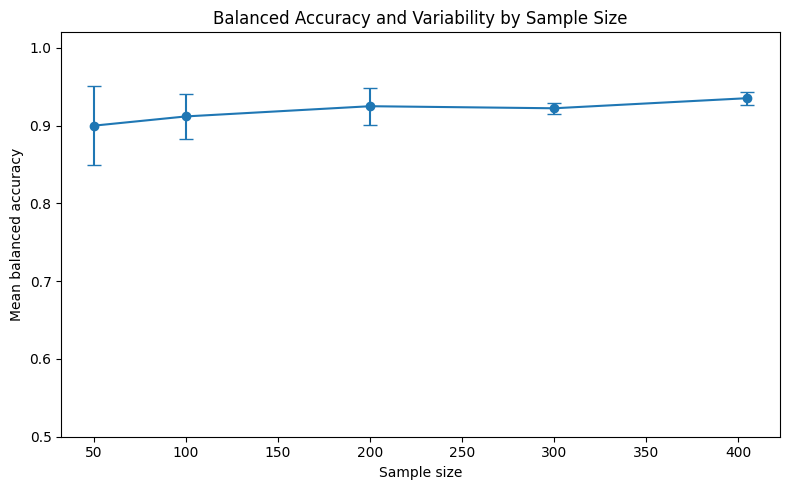

In [81]:
balanced_accuracy_summary = (
    sample_size_results
    .groupby("sample_size")["balanced_accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    balanced_accuracy_summary["sample_size"],
    balanced_accuracy_summary["mean"],
    yerr=balanced_accuracy_summary["std"],
    marker="o",
    capsize=5
)

plt.xlabel("Sample size")
plt.ylabel("Mean balanced accuracy")
plt.title(
    "Balanced Accuracy and Variability by Sample Size"
)

plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

In [82]:
sample_size_results.to_csv(
    RESULTS_DIR
    / "GSE81538_sample_size_experiment_results.csv",
    index=False
)

sample_size_summary_long.to_csv(
    RESULTS_DIR
    / "GSE81538_sample_size_experiment_summary.csv",
    index=False
)

print("Sample-size experiment results saved.")

Sample-size experiment results saved.


In [84]:
from itertools import combinations

import numpy as np
import pandas as pd

from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    f_classif,
)
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

# Development sample sizes for the 405-tumor sensitivity cohort
sample_sizes = [
    50,
    100,
    200,
    300,
    len(y_primary)
]

number_of_repetitions = 10
number_of_selected_genes = 1000

# Reset these objects whenever this cell is rerun
selected_gene_sets = []
selection_records = []

# Integer positions avoid pandas/Arrow index compatibility errors
all_positions = np.arange(len(y_primary))

for sample_size in sample_sizes:
    print(f"Processing sample size: {sample_size}")

    for repetition in range(number_of_repetitions):

        if sample_size == len(y_primary):
            selected_positions = all_positions.copy()

        else:
            selected_positions, _ = train_test_split(
                all_positions,
                train_size=sample_size,
                random_state=repetition,
                stratify=np.asarray(y_primary)
            )

        X_subset = X_primary.iloc[selected_positions].copy()
        y_subset = y_primary.iloc[selected_positions].copy()

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        for fold, (training_positions, _) in enumerate(
            cv.split(X_subset, y_subset),
            start=1
        ):
            X_fold_train = X_subset.iloc[training_positions].copy()
            y_fold_train = y_subset.iloc[training_positions].copy()

            # Remove constant genes using the training fold only
            variance_filter = VarianceThreshold(
                threshold=0.0
            )

            X_variance_filtered = variance_filter.fit_transform(
                X_fold_train
            )

            available_genes = X_fold_train.columns[
                variance_filter.get_support()
            ]

            k = min(
                number_of_selected_genes,
                len(available_genes)
            )

            selector = SelectKBest(
                score_func=f_classif,
                k=k
            )

            selector.fit(
                X_variance_filtered,
                y_fold_train
            )

            selected_genes = available_genes[
                selector.get_support()
            ].tolist()

            set_id = (
                f"n{sample_size}_"
                f"rep{repetition + 1}_"
                f"fold{fold}"
            )

            selected_gene_sets.append({
                "sample_size": sample_size,
                "repetition": repetition + 1,
                "fold": fold,
                "set_id": set_id,
                "genes": set(selected_genes)
            })

            for gene in selected_genes:
                selection_records.append({
                    "sample_size": sample_size,
                    "repetition": repetition + 1,
                    "fold": fold,
                    "set_id": set_id,
                    "gene": gene
                })

selection_records = pd.DataFrame(
    selection_records
)

print("\nFeature-selection experiment completed.")
print(
    "Number of fitted feature selectors:",
    len(selected_gene_sets)
)

# Verification checks
assert len(selected_gene_sets) == 250
assert set(selection_records["sample_size"].unique()) == {
    50,
    100,
    200,
    300,
    405
}

print("Sensitivity feature-selection analysis verified.")

Processing sample size: 50


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [16921] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12650] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selec

Processing sample size: 100


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12850] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


Processing sample size: 200


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [12920] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Processing sample size: 300
Processing sample size: 405

Feature-selection experiment completed.
Number of fitted feature selectors: 250
Sensitivity feature-selection analysis verified.


In [85]:
jaccard_results = []

for sample_size in sample_sizes:

    sets_for_size = [
        result
        for result in selected_gene_sets
        if result["sample_size"] == sample_size
    ]

    for first, second in combinations(sets_for_size, 2):

        intersection = len(
            first["genes"].intersection(second["genes"])
        )

        union = len(
            first["genes"].union(second["genes"])
        )

        jaccard = intersection / union

        jaccard_results.append({
            "sample_size": sample_size,
            "first_set": first["set_id"],
            "second_set": second["set_id"],
            "jaccard_similarity": jaccard
        })

jaccard_results = pd.DataFrame(jaccard_results)

jaccard_summary = (
    jaccard_results
    .groupby("sample_size")["jaccard_similarity"]
    .agg([
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
    .reset_index()
)

display(jaccard_summary.round(4))

,sample_size,mean,std,min,median,max
0,50,0.2510,0.0777,0.1268,0.2338,0.6129
1,100,0.3967,0.0672,0.2895,0.3831,0.6722
2,200,0.5450,0.0504,0.4184,0.5385,0.7559
3,300,0.6659,0.0304,0.5662,0.6639,0.7575
4,405,0.7693,0.0206,0.6835,0.7699,0.8282


In [86]:
selection_frequency = (
    selection_records
    .groupby(
        ["sample_size", "gene"]
    )
    .size()
    .reset_index(name="times_selected")
)

number_of_runs_per_size = (
    number_of_repetitions * 5
)

selection_frequency["selection_frequency"] = (
    selection_frequency["times_selected"]
    / number_of_runs_per_size
)

top_stable_genes = (
    selection_frequency
    .sort_values(
        ["sample_size", "selection_frequency"],
        ascending=[True, False]
    )
    .groupby("sample_size")
    .head(20)
)

display(top_stable_genes)

,sample_size,gene,times_selected,selection_frequency
140,50,AGR2,50,1.0
141,50,AGR3,50,1.0
790,50,C6orf97,50,1.0
832,50,CA12,50,1.0
1238,50,CMBL,50,1.0
1530,50,DEGS2,50,1.0
1617,50,DNALI1,50,1.0
1815,50,ERBB4,50,1.0
1830,50,ESR1,50,1.0
2014,50,FBP1,50,1.0


In [87]:
stable_gene_counts = (
    selection_frequency
    .assign(
        selected_at_least_50=lambda df:
            df["selection_frequency"] >= 0.50,
        selected_at_least_80=lambda df:
            df["selection_frequency"] >= 0.80
    )
    .groupby("sample_size")
    .agg(
        genes_selected_at_least_50=(
            "selected_at_least_50",
            "sum"
        ),
        genes_selected_at_least_80=(
            "selected_at_least_80",
            "sum"
        )
    )
    .reset_index()
    .sort_values("sample_size")
)

display(stable_gene_counts)

,sample_size,genes_selected_at_least_50,genes_selected_at_least_80
0,50,518,145
1,100,765,361
2,200,881,561
3,300,937,696
4,405,965,808


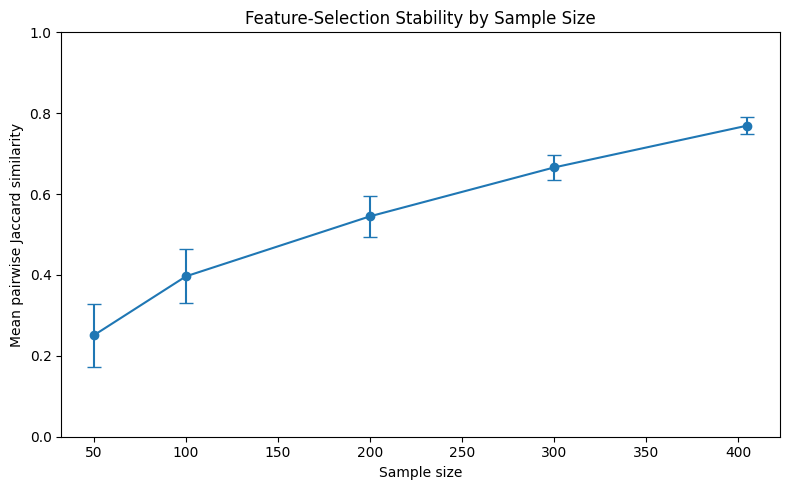

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.errorbar(
    jaccard_summary["sample_size"],
    jaccard_summary["mean"],
    yerr=jaccard_summary["std"],
    marker="o",
    capsize=5
)

plt.xlabel("Sample size")
plt.ylabel("Mean pairwise Jaccard similarity")
plt.title("Feature-Selection Stability by Sample Size")

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [89]:
selection_records.to_csv(
    RESULTS_DIR / "GSE81538_gene_selection_records.csv",
    index=False
)

jaccard_results.to_csv(
    RESULTS_DIR / "GSE81538_feature_jaccard_results.csv",
    index=False
)

jaccard_summary.to_csv(
    RESULTS_DIR / "GSE81538_feature_jaccard_summary.csv",
    index=False
)

selection_frequency.to_csv(
    RESULTS_DIR / "GSE81538_gene_selection_frequencies.csv",
    index=False
)

print("Feature-stability results saved.")

Feature-stability results saved.


In [90]:
# Identify the 20 most frequently selected genes
# within each development sample-size condition.

top_stable_genes = (
    selection_frequency
    .sort_values(
        ["sample_size", "selection_frequency", "times_selected", "gene"],
        ascending=[True, False, False, True]
    )
    .groupby(
        "sample_size",
        group_keys=False
    )
    .head(20)
    .reset_index(drop=True)
)

# Save the complete top-gene table.
top_stable_genes.to_csv(
    RESULTS_DIR / "GSE81538_top_20_stable_genes_by_sample_size.csv",
    index=False
)

# Display the main reporting columns.
display(
    top_stable_genes[
        [
            "sample_size",
            "gene",
            "times_selected",
            "selection_frequency"
        ]
    ]
)

print(
    "Top 20 stable genes by sample size saved successfully."
)

,sample_size,gene,times_selected,selection_frequency
0,50,AGR2,50,1.0
1,50,AGR3,50,1.0
2,50,C6orf97,50,1.0
3,50,CA12,50,1.0
4,50,CMBL,50,1.0
5,50,DEGS2,50,1.0
6,50,DNALI1,50,1.0
7,50,ERBB4,50,1.0
8,50,ESR1,50,1.0
9,50,FBP1,50,1.0


Top 20 stable genes by sample size saved successfully.


In [55]:
comparison_genes = top_stable_genes[
    top_stable_genes["sample_size"].isin(
        [50, len(y_primary)]
    )
].copy()

display(comparison_genes)

,sample_size,gene,times_selected,selection_frequency
1,50,A2ML1,50,1.0
126,50,AGR2,50,1.0
127,50,AGR3,50,1.0
234,50,ANXA9,50,1.0
670,50,C1orf64,50,1.0
768,50,C6orf97,50,1.0
816,50,CA12,50,1.0
1227,50,CMBL,50,1.0
1529,50,DEGS2,50,1.0
1654,50,DSC2,50,1.0


In [91]:
stable_gene_counts = (
    selection_frequency
    .assign(
        highly_stable=lambda data:
        data["selection_frequency"] >= 0.80
    )
    .groupby("sample_size")["highly_stable"]
    .sum()
    .reset_index(name="genes_selected_in_at_least_80_percent")
)

display(stable_gene_counts)

,sample_size,genes_selected_in_at_least_80_percent
0,50,145
1,100,361
2,200,561
3,300,696
4,405,808


In [92]:
stable_gene_counts = (
    selection_frequency
    .assign(
        selected_at_least_50_percent=
            selection_frequency["selection_frequency"] >= 0.50,
        selected_at_least_80_percent=
            selection_frequency["selection_frequency"] >= 0.80
    )
    .groupby("sample_size")
    .agg(
        genes_selected_in_at_least_50_percent=(
            "selected_at_least_50_percent",
            "sum"
        ),
        genes_selected_in_at_least_80_percent=(
            "selected_at_least_80_percent",
            "sum"
        )
    )
    .reset_index()
    .sort_values("sample_size")
)

stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_stable_gene_counts.csv",
    index=False
)

display(stable_gene_counts)

print("Complete stable-gene count summary saved successfully.")

,sample_size,genes_selected_in_at_least_50_percent,genes_selected_in_at_least_80_percent
0,50,518,145
1,100,765,361
2,200,881,561
3,300,937,696
4,405,965,808


Complete stable-gene count summary saved successfully.


In [93]:
moderately_stable_gene_counts = (
    selection_frequency
    .assign(
        selected_at_least_half=lambda data:
        data["selection_frequency"] >= 0.50
    )
    .groupby("sample_size")["selected_at_least_half"]
    .sum()
    .reset_index(name="genes_selected_in_at_least_50_percent")
)

display(moderately_stable_gene_counts)

,sample_size,genes_selected_in_at_least_50_percent
0,50,518
1,100,765
2,200,881
3,300,937
4,405,965


In [60]:
top_stable_genes.to_csv(
    RESULTS_DIR / "GSE81538_top_stable_genes_by_sample_size.csv",
    index=False
)

stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_highly_stable_gene_counts.csv",
    index=False
)

moderately_stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_moderately_stable_gene_counts.csv",
    index=False
)

In [94]:
# Create separate 50% and 80% threshold tables
genes_selected_at_least_50 = stable_gene_counts[
    [
        "sample_size",
        "genes_selected_in_at_least_50_percent"
    ]
].copy()

genes_selected_at_least_80 = stable_gene_counts[
    [
        "sample_size",
        "genes_selected_in_at_least_80_percent"
    ]
].copy()

# Save the complete combined summary
stable_gene_counts.to_csv(
    RESULTS_DIR / "GSE81538_405_stable_gene_counts_complete.csv",
    index=False
)

# Save the separate threshold summaries
genes_selected_at_least_50.to_csv(
    RESULTS_DIR / "GSE81538_405_genes_selected_at_least_50_percent.csv",
    index=False
)

genes_selected_at_least_80.to_csv(
    RESULTS_DIR / "GSE81538_405_genes_selected_at_least_80_percent.csv",
    index=False
)

print("Complete and separate gene-stability count tables saved.")

Complete and separate gene-stability count tables saved.


In [97]:
# Coefficient-direction stability analysis for the
# 405-tumor GSE81538 sensitivity cohort.

import numpy as np
import pandas as pd

from sklearn.feature_selection import (
    SelectKBest,
    VarianceThreshold,
    f_classif,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler


# Development sample sizes.
# len(y_primary) should equal 405 in this sensitivity notebook.
sample_sizes = [
    50,
    100,
    200,
    300,
    len(y_primary)
]

number_of_repetitions = 10
number_of_selected_genes = 1000

# Reset the records whenever this cell is rerun.
coefficient_records = []

# Use integer positions to avoid pandas/Arrow index errors.
all_positions = np.arange(len(y_primary))


for sample_size in sample_sizes:
    print(f"Processing sample size: {sample_size}")

    for repetition in range(number_of_repetitions):

        # Use all 405 tumors for the full-cohort condition.
        if sample_size == len(y_primary):
            selected_positions = all_positions.copy()

        # Draw a stratified subset for smaller sample sizes.
        else:
            selected_positions, _ = train_test_split(
                all_positions,
                train_size=sample_size,
                random_state=repetition,
                stratify=np.asarray(y_primary)
            )

        X_subset = X_primary.iloc[selected_positions].copy()
        y_subset = y_primary.iloc[selected_positions].copy()

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=repetition
        )

        for fold, (training_positions, _) in enumerate(
            cv.split(
                X_subset,
                np.asarray(y_subset)
            ),
            start=1
        ):
            X_fold_train = X_subset.iloc[
                training_positions
            ].copy()

            y_fold_train = y_subset.iloc[
                training_positions
            ].copy()

            # Remove constant genes using only the training fold.
            variance_filter = VarianceThreshold(
                threshold=0.0
            )

            X_variance_filtered = (
                variance_filter.fit_transform(
                    X_fold_train
                )
            )

            available_genes = X_fold_train.columns[
                variance_filter.get_support()
            ]

            # Select up to 1,000 genes using the ANOVA F-score.
            k = min(
                number_of_selected_genes,
                len(available_genes)
            )

            selector = SelectKBest(
                score_func=f_classif,
                k=k
            )

            X_selected = selector.fit_transform(
                X_variance_filtered,
                y_fold_train
            )

            selected_genes = available_genes[
                selector.get_support()
            ].tolist()

            # Standardize the selected genes before fitting
            # logistic regression so coefficients are comparable.
            scaler = StandardScaler()

            X_selected_scaled = scaler.fit_transform(
                X_selected
            )

            coefficient_model = LogisticRegression(
                penalty="l2",
                C=1.0,
                class_weight="balanced",
                solver="liblinear",
                max_iter=5000,
                random_state=repetition
            )

            coefficient_model.fit(
                X_selected_scaled,
                y_fold_train
            )

            coefficients = (
                coefficient_model.coef_
                .ravel()
            )

            set_id = (
                f"n{sample_size}_"
                f"rep{repetition + 1}_"
                f"fold{fold}"
            )

            for gene, coefficient in zip(
                selected_genes,
                coefficients
            ):
                coefficient_sign = int(
                    np.sign(coefficient)
                )

                if coefficient_sign > 0:
                    direction_label = "positive"
                elif coefficient_sign < 0:
                    direction_label = "negative"
                else:
                    direction_label = "zero"

                coefficient_records.append({
                    "sample_size": sample_size,
                    "repetition": repetition + 1,
                    "random_seed": repetition,
                    "fold": fold,
                    "set_id": set_id,
                    "gene": gene,
                    "coefficient": float(coefficient),
                    "standardized_coefficient": float(
                        coefficient
                    ),
                    "direction": coefficient_sign,
                    "coefficient_sign": coefficient_sign,
                    "direction_label": direction_label
                })


coefficient_records = pd.DataFrame(
    coefficient_records
)

# Verification checks.
expected_sample_sizes = {
    50,
    100,
    200,
    300,
    405
}

observed_sample_sizes = set(
    coefficient_records["sample_size"]
    .astype(int)
    .unique()
)

number_of_fitted_models = (
    coefficient_records["set_id"]
    .nunique()
)

assert observed_sample_sizes == expected_sample_sizes
assert number_of_fitted_models == 250

# Save the full coefficient-level sensitivity results.
coefficient_records.to_csv(
    RESULTS_DIR /
    "GSE81538_405_coefficient_direction_records.csv",
    index=False
)

print(
    "\nCoefficient-direction experiment completed."
)

print(
    "Number of fitted coefficient models:",
    number_of_fitted_models
)

print(
    "Number of coefficient records:",
    len(coefficient_records)
)

print(
    "405-tumor coefficient-direction analysis verified "
    "and saved."
)

Processing sample size: 50


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [16921] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureW

Processing sample size: 100


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Processing sample size: 200


...

Processing sample size: 300


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr

Processing sample size: 405


C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\kumia\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was depr


Coefficient-direction experiment completed.
Number of fitted coefficient models: 250
Number of coefficient records: 250000
405-tumor coefficient-direction analysis verified and saved.


In [99]:
# Summarize coefficient-selection and direction stability
# for the 405-tumor sensitivity analysis.

import numpy as np
import pandas as pd

# Confirm that the required columns exist.
required_columns = {
    "sample_size",
    "gene",
    "set_id",
    "coefficient"
}

missing_columns = required_columns.difference(
    coefficient_records.columns
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

# Work from a fresh copy.
coefficient_records_summary = coefficient_records.copy()

# Create the absolute-coefficient column that was missing
# from the previous code.
coefficient_records_summary["absolute_coefficient"] = (
    coefficient_records_summary["coefficient"].abs()
)

# Determine the number of fitted models at each sample size.
runs_per_sample_size = (
    coefficient_records_summary
    .groupby("sample_size")["set_id"]
    .nunique()
    .rename("number_of_model_fits")
    .reset_index()
)

# Create one summary row for each gene within each sample size.
coefficient_stability = (
    coefficient_records_summary
    .groupby(
        ["sample_size", "gene"],
        as_index=False
    )
    .agg(
        times_selected=(
            "set_id",
            "nunique"
        ),
        mean_coefficient=(
            "coefficient",
            "mean"
        ),
        coefficient_sd=(
            "coefficient",
            "std"
        ),
        mean_absolute_coefficient=(
            "absolute_coefficient",
            "mean"
        ),
        positive_count=(
            "coefficient",
            lambda values: int((values > 0).sum())
        ),
        negative_count=(
            "coefficient",
            lambda values: int((values < 0).sum())
        ),
        zero_count=(
            "coefficient",
            lambda values: int((values == 0).sum())
        )
    )
    .merge(
        runs_per_sample_size,
        on="sample_size",
        how="left"
    )
)

# Proportion of all model fits in which the gene was selected.
coefficient_stability["selection_frequency"] = (
    coefficient_stability["times_selected"]
    / coefficient_stability["number_of_model_fits"]
)

# Proportion of selections having the dominant coefficient direction.
coefficient_stability["direction_consistency"] = (
    coefficient_stability[
        ["positive_count", "negative_count"]
    ]
    .max(axis=1)
    / coefficient_stability["times_selected"]
)

# Coefficient variability relative to mean absolute magnitude.
# Avoid division by zero.
coefficient_stability["coefficient_cv"] = np.where(
    coefficient_stability["mean_absolute_coefficient"] > 0,
    coefficient_stability["coefficient_sd"]
    / coefficient_stability["mean_absolute_coefficient"],
    np.nan
)

# Indicate whether the dominant direction is positive or negative.
coefficient_stability["dominant_direction"] = np.where(
    coefficient_stability["positive_count"]
    >= coefficient_stability["negative_count"],
    "positive",
    "negative"
)

# Verify the sensitivity-analysis sample sizes.
expected_sample_sizes = {50, 100, 200, 300, 405}

observed_sample_sizes = set(
    coefficient_stability["sample_size"]
    .astype(int)
    .unique()
)

assert observed_sample_sizes == expected_sample_sizes, (
    f"Unexpected sample sizes: {observed_sample_sizes}"
)

# Verify that each sample-size condition had 50 fitted models.
assert set(
    coefficient_stability["number_of_model_fits"]
    .astype(int)
    .unique()
) == {50}

# Save the complete gene-level coefficient-stability table.
coefficient_stability.to_csv(
    RESULTS_DIR /
    "GSE81538_405_coefficient_stability_by_gene.csv",
    index=False
)

display(
    coefficient_stability.head()
)

print(
    "405-tumor coefficient-stability summary "
    "calculated and saved successfully."
)

,sample_size,gene,times_selected,mean_coefficient,coefficient_sd,mean_absolute_coefficient,positive_count,negative_count,zero_count,number_of_model_fits,selection_frequency,direction_consistency,coefficient_cv,dominant_direction
0,50,A1BG,9,0.012197,0.017956,0.015688,8,1,0,50,0.18,0.888889,1.144568,positive
1,50,A2ML1,48,-0.020526,0.017149,0.022617,7,41,0,50,0.96,0.854167,0.758246,negative
2,50,AAAS,3,0.024903,0.007734,0.024903,3,0,0,50,0.06,1.000000,0.310571,positive
3,50,AADAT,24,-0.007877,0.020398,0.019181,6,18,0,50,0.48,0.750000,1.063429,negative
4,50,AAGAB,11,0.002784,0.008116,0.006657,6,5,0,50,0.22,0.545455,1.219197,positive


405-tumor coefficient-stability summary calculated and saved successfully.


In [64]:
# Focus on genes selected in at least half of the 50 runs
frequently_selected_coefficients = (
    coefficient_stability[
        coefficient_stability["selection_frequency"] >= 0.50
    ]
    .copy()
)

explanation_summary = (
    frequently_selected_coefficients
    .groupby("sample_size")
    .agg(
        frequently_selected_genes=("gene", "count"),
        mean_direction_consistency=(
            "direction_consistency",
            "mean"
        ),
        median_direction_consistency=(
            "direction_consistency",
            "median"
        ),
        genes_with_complete_direction_agreement=(
            "direction_consistency",
            lambda values: (values == 1.0).sum()
        ),
        mean_coefficient_sd=(
            "coefficient_sd",
            "mean"
        )
    )
    .reset_index()
)

display(explanation_summary.round(4))

,sample_size,frequently_selected_genes,mean_direction_consistency,median_direction_consistency,genes_with_complete_direction_agreement,mean_coefficient_sd
0,50,547,0.8326,0.8800,94,0.0135
1,100,793,0.7928,0.8200,123,0.0193
2,200,892,0.8080,0.8289,140,0.0255
3,300,943,0.8375,0.8889,205,0.0270
4,397,969,0.8848,0.9600,352,0.0234


In [100]:
# Summarize coefficient-direction stability among genes
# selected in at least 50% of the 50 model fits.

frequently_selected_coefficients = (
    coefficient_stability[
        coefficient_stability["selection_frequency"] >= 0.50
    ]
    .copy()
)

# A gene is directionally stable when its coefficient has
# the same dominant sign in at least 90% of its selections.
frequently_selected_coefficients[
    "directionally_stable"
] = (
    frequently_selected_coefficients[
        "direction_consistency"
    ] >= 0.90
)

direction_stability_summary = (
    frequently_selected_coefficients
    .groupby("sample_size")
    .agg(
        frequently_selected_genes=(
            "gene",
            "count"
        ),
        directionally_stable_genes=(
            "directionally_stable",
            "sum"
        ),
        mean_direction_consistency=(
            "direction_consistency",
            "mean"
        ),
        median_direction_consistency=(
            "direction_consistency",
            "median"
        )
    )
    .reset_index()
    .sort_values("sample_size")
)

direction_stability_summary[
    "proportion_directionally_stable"
] = (
    direction_stability_summary[
        "directionally_stable_genes"
    ]
    / direction_stability_summary[
        "frequently_selected_genes"
    ]
)

direction_stability_summary[
    "percent_directionally_stable"
] = (
    100
    * direction_stability_summary[
        "proportion_directionally_stable"
    ]
)

# Verify that this is the 405-tumor sensitivity analysis.
assert direction_stability_summary[
    "sample_size"
].tolist() == [
    50,
    100,
    200,
    300,
    405
]

# Save the gene-level and summary tables.
frequently_selected_coefficients.to_csv(
    RESULTS_DIR
    / "GSE81538_405_frequently_selected_gene_direction_stability.csv",
    index=False
)

direction_stability_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_405_direction_stability_summary.csv",
    index=False
)

display(
    direction_stability_summary.round(4)
)

print(
    "405-tumor coefficient-direction stability "
    "summary calculated and saved."
)

,sample_size,frequently_selected_genes,directionally_stable_genes,mean_direction_consistency,median_direction_consistency,proportion_directionally_stable,percent_directionally_stable
0,50,518,196,0.8137,0.8492,0.3784,37.8378
1,100,765,200,0.7717,0.7800,0.2614,26.1438
2,200,881,257,0.7748,0.7778,0.2917,29.1714
3,300,937,386,0.8177,0.8400,0.4120,41.1953
4,405,965,542,0.8653,0.9318,0.5617,56.1658


405-tumor coefficient-direction stability summary calculated and saved.


In [65]:
direction_stability_counts = (
    frequently_selected_coefficients
    .assign(
        stable_direction=lambda df:
        df["direction_consistency"] >= 0.90
    )
    .groupby("sample_size")
    .agg(
        frequently_selected_genes=("gene", "count"),
        directionally_stable_genes=(
            "stable_direction",
            "sum"
        )
    )
    .reset_index()
)

direction_stability_counts[
    "percentage_directionally_stable"
] = (
    100
    * direction_stability_counts[
        "directionally_stable_genes"
    ]
    / direction_stability_counts[
        "frequently_selected_genes"
    ]
)

display(direction_stability_counts.round(2))

,sample_size,frequently_selected_genes,directionally_stable_genes,percentage_directionally_stable
0,50,547,242,44.24
1,100,793,269,33.92
2,200,892,337,37.78
3,300,943,460,48.78
4,397,969,601,62.02


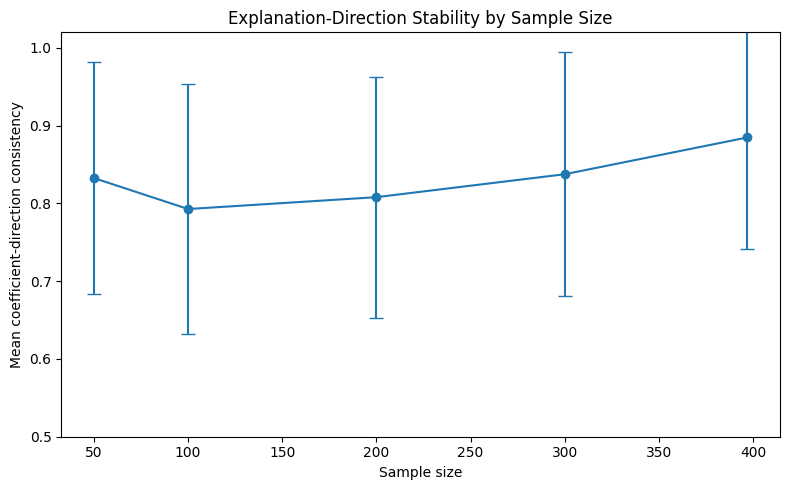

In [66]:
direction_plot_data = (
    frequently_selected_coefficients
    .groupby("sample_size")["direction_consistency"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(8, 5))

plt.errorbar(
    direction_plot_data["sample_size"],
    direction_plot_data["mean"],
    yerr=direction_plot_data["std"],
    marker="o",
    capsize=5
)

plt.xlabel("Sample size")
plt.ylabel("Mean coefficient-direction consistency")
plt.title("Explanation-Direction Stability by Sample Size")
plt.ylim(0.5, 1.02)
plt.tight_layout()
plt.show()

<Figure size 900x600 with 0 Axes>

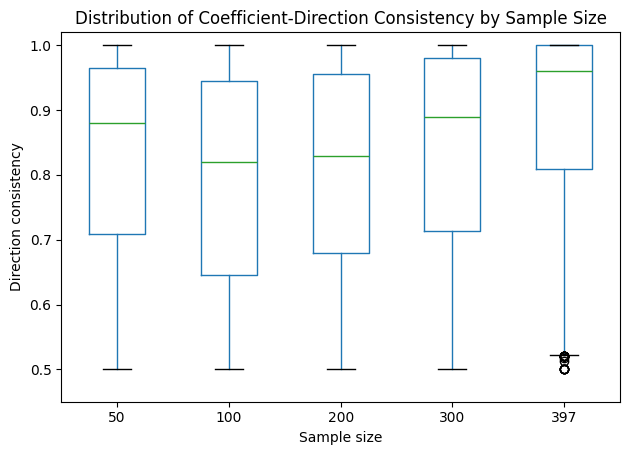

In [67]:
plot_data = frequently_selected_coefficients[
    [
        "sample_size",
        "gene",
        "direction_consistency"
    ]
].copy()

plt.figure(figsize=(9, 6))

plot_data.boxplot(
    column="direction_consistency",
    by="sample_size",
    grid=False
)

plt.suptitle("")
plt.title(
    "Distribution of Coefficient-Direction Consistency "
    "by Sample Size"
)
plt.xlabel("Sample size")
plt.ylabel("Direction consistency")
plt.ylim(0.45, 1.02)
plt.tight_layout()
plt.show()

In [68]:
direction_stability_counts.to_csv(
    RESULTS_DIR
    / "GSE81538_directionally_stable_gene_counts.csv",
    index=False
)

direction_distribution_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_direction_consistency_distribution.csv",
    index=False
)

frequently_selected_coefficients.to_csv(
    RESULTS_DIR
    / "GSE81538_frequently_selected_gene_coefficients.csv",
    index=False
)

print("Explanation-stability results saved.")

NameError: name 'direction_distribution_summary' is not defined

In [69]:
direction_distribution_summary = (
    frequently_selected_coefficients
    .groupby("sample_size")["direction_consistency"]
    .agg(
        gene_count="count",
        mean="mean",
        standard_deviation="std",
        minimum="min",
        q25=lambda values: values.quantile(0.25),
        median="median",
        q75=lambda values: values.quantile(0.75),
        maximum="max"
    )
    .reset_index()
)

display(direction_distribution_summary.round(4))

,sample_size,gene_count,mean,standard_deviation,minimum,q25,median,q75,maximum
0,50,547,0.8326,0.1492,0.5,0.7090,0.8800,0.9643,1.0
1,100,793,0.7928,0.1612,0.5,0.6452,0.8200,0.9444,1.0
2,200,892,0.8080,0.1551,0.5,0.6800,0.8289,0.9560,1.0
3,300,943,0.8375,0.1570,0.5,0.7127,0.8889,0.9800,1.0
4,397,969,0.8848,0.1436,0.5,0.8085,0.9600,1.0000,1.0


In [70]:
print("direction_stability_counts exists:",
      "direction_stability_counts" in globals())

print("direction_distribution_summary exists:",
      "direction_distribution_summary" in globals())

print("frequently_selected_coefficients exists:",
      "frequently_selected_coefficients" in globals())

direction_stability_counts exists: True
direction_distribution_summary exists: True
frequently_selected_coefficients exists: True


In [71]:
direction_stability_counts.to_csv(
    RESULTS_DIR
    / "GSE81538_directionally_stable_gene_counts.csv",
    index=False
)

direction_distribution_summary.to_csv(
    RESULTS_DIR
    / "GSE81538_direction_consistency_distribution.csv",
    index=False
)

frequently_selected_coefficients.to_csv(
    RESULTS_DIR
    / "GSE81538_frequently_selected_gene_coefficients.csv",
    index=False
)

print("Explanation-stability results saved.")

Explanation-stability results saved.


In [72]:
full_sample_coefficients = (
    frequently_selected_coefficients[
        frequently_selected_coefficients["sample_size"] == 397
    ]
    .copy()
)

stable_full_sample_genes = (
    full_sample_coefficients[
        full_sample_coefficients["direction_consistency"] >= 0.90
    ]
    .sort_values(
        [
            "selection_frequency",
            "direction_consistency",
            "mean_absolute_coefficient"
        ],
        ascending=False
    )
)

unstable_full_sample_genes = (
    full_sample_coefficients[
        full_sample_coefficients["direction_consistency"] < 0.70
    ]
    .sort_values(
        [
            "direction_consistency",
            "selection_frequency"
        ],
        ascending=[True, False]
    )
)

print(
    "Stable genes at n=397:",
    len(stable_full_sample_genes)
)

print(
    "Unstable genes at n=397:",
    len(unstable_full_sample_genes)
)

display(
    stable_full_sample_genes[
        [
            "gene",
            "selection_frequency",
            "mean_coefficient",
            "coefficient_sd",
            "direction_consistency",
            "mean_absolute_coefficient"
        ]
    ].head(25).round(4)
)

display(
    unstable_full_sample_genes[
        [
            "gene",
            "selection_frequency",
            "mean_coefficient",
            "coefficient_sd",
            "direction_consistency",
            "mean_absolute_coefficient"
        ]
    ].head(25).round(4)
)

Stable genes at n=397: 601
Unstable genes at n=397: 141


,gene,selection_frequency,mean_coefficient,coefficient_sd,direction_consistency,mean_absolute_coefficient
15427,KBTBD12,1.0,-0.1844,0.0283,1.0,0.1844
15233,FBN3,1.0,-0.1712,0.0328,1.0,0.1712
16047,SLC4A8,1.0,0.1645,0.0189,1.0,0.1645
16076,SOX11,1.0,-0.1568,0.0329,1.0,0.1568
14843,C11orf86,1.0,-0.1556,0.0274,1.0,0.1556
16045,SLC44A4,1.0,0.1443,0.0234,1.0,0.1443
15682,NKX1-2,1.0,-0.1429,0.0366,1.0,0.1429
15155,EID1,1.0,0.1410,0.0305,1.0,0.1410
14714,ACE2,1.0,-0.1374,0.0267,1.0,0.1374
15832,PRDM13,1.0,-0.1371,0.0212,1.0,0.1371


,gene,selection_frequency,mean_coefficient,coefficient_sd,direction_consistency,mean_absolute_coefficient
15902,RASGEF1B,1.00,-0.0012,0.0287,0.5000,0.0214
15936,RNASE4,1.00,-0.0012,0.0255,0.5000,0.0210
16314,ZIC1,1.00,0.0006,0.0268,0.5000,0.0207
15821,PPARGC1B,0.88,-0.0042,0.0226,0.5000,0.0193
16201,TMEM26,0.60,0.0009,0.0158,0.5000,0.0125
15854,PRSS3,0.56,-0.0095,0.0450,0.5000,0.0353
14968,CDC45,0.78,0.0003,0.0113,0.5128,0.0092
14986,CEACAM19,0.58,0.0024,0.0355,0.5172,0.0302
14772,ARL3,1.00,-0.0004,0.0157,0.5200,0.0122
14948,CCDC96,1.00,-0.0001,0.0132,0.5200,0.0102


In [73]:
stable_full_sample_genes.to_csv(
    RESULTS_DIR
    / "GSE81538_stable_explanatory_genes_n397.csv",
    index=False
)

unstable_full_sample_genes.to_csv(
    RESULTS_DIR
    / "GSE81538_unstable_explanatory_genes_n397.csv",
    index=False
)

print("Stable and unstable explanatory gene lists saved.")

Stable and unstable explanatory gene lists saved.
